# Forward model for DAS sensitivity 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pykonal 
from pykonal.transformations import geo2sph, sph2geo
import pandas as pd
from tqdm import tqdm
import glob
import re

from DAS_sensitivity_function import *

import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

In [2]:
# datafram containing all the channels's location 
df = pd.read_csv(r'C:\Users\liliv\Desktop\Fagradalfjall\DAS_metadata\all_channel_info.csv', index_col=0)
folder = r'C:\Users\liliv\Desktop\codes\DAS\Data_DAS_sensitivity\ttime_grids'

folder_out = r'C:\Users\liliv\Desktop\Fagradalfjall\Amplitude information'

file_name = 'M2.5_971259' 
# coordinates of the seismic source 

source_coord = np.array([63.926 ,-21.995, 6]) # (lat lon depth)


'''truck_azimuth = 36.73
truck_dip = 1.28'''


#source_name_list, source_description_list = Truck_source(['P', 'L', 'T'], truck_azimuth, truck_dip)
#source_name_list, source_description_list = SF_combinations (50)
source_name_list, source_description_list = [file_name], ['False']



# MC error hestimate
receiver_error = 3.55
source_error = 1.07
MC_sample_numeber = 100

In [3]:
# Wave type to considerate in computation 
wave_type_list = ['P','SV', 'SH']

''' 
for a moment tensor : np.array([[0, 0, 0],
                                [0, 0, 0],
                                [0, 0, 1]]) 
              
    signle force :      np.array([0,0,1])          '''


# Pykonal specific

latitudes = xr.load_dataarray(glob.glob(folder+'//*')[0]).coords['latitude'].values
longitudes = xr.load_dataarray(glob.glob(folder+'//*')[0]).coords['longitude'].values
depths = xr.load_dataarray(glob.glob(folder+'//*')[0]).coords['depth'].values

# node spacing
grid_spacing = (
    np.abs(depths[1] - depths[0]),
    np.deg2rad(np.abs(latitudes[1] - latitudes[0])),
    np.deg2rad(np.abs(longitudes[1] - longitudes[0])),)


# give the shape of your grid, here use the first grid of dataset and extract variable 
model_shape = xr.load_dataarray(glob.glob(folder+'/*')[0]).transpose( 'depth','latitude', 'longitude').values.shape


reference_point = geo2sph((latitudes.max(), longitudes.min(), depths.max()))

print('min coord')
print(reference_point)
print('max value')
print(reference_point + (np.array(grid_spacing)*model_shape))
print('source loc')
print(np.array(geo2sph(source_coord).squeeze()) )
print('grid spacing')
print(grid_spacing)
print('model shape')
print (model_shape)


# ==> node_interval = distance between adjacent  nodes for: depth (m), latitude (radians), longitude (radians).
# ==> The units for nodal distance are m,rad,rad for spherical model but becoms m, m, m for carteian model
# ==> !!! lat and lon in radians because model in spherical coordinates (mandatory for PointSourceSolver) otherwise can create a cartesian model, then units are not the same.


min coord
[ 6.34100000e+03  4.54251608e-01 -3.90707486e-01]
max value
[ 6.37331683e+03  4.56602161e-01 -3.82027722e-01]
source loc
[ 6.36500000e+03  4.55077149e-01 -3.83885169e-01]
grid spacing
(0.3168316831683171, 2.350553021897824e-05, 8.593826703897365e-05)
model shape
(102, 100, 101)


In [4]:
### Initialize the solver once with constant grid settings ###

solver = pykonal.solver.PointSourceSolver(coord_sys="spherical")
# Set up grid properties
solver.velocity.min_coords = reference_point
solver.velocity.node_intervals = grid_spacing
solver.velocity.npts = model_shape  # Ensure shape matches the travel time grid


# Create DataFrame to hold results 
result_container = pd.DataFrame(columns=source_name_list)

all_files = glob.glob(folder+'//*')
number_only = [int(number.split('\\')[-1].split('.')[0]) for number in all_files]
number_only = sorted(number_only)

In [5]:
import numpy as np

R_EARTH = 6371000.0  # m, mean Earth radius (change if you want WGS84 ellipsoid)

def latlon_depth_to_ecef(lat_deg, lon_deg, depth_m, R=R_EARTH):
    """Convert lat, lon (deg) and depth (m, positive downward) to ECEF (m)."""
    lat = np.radians(lat_deg)
    lon = np.radians(lon_deg)
    r = R - depth_m  # radius from Earth's center to the point
    x = r * np.cos(lat) * np.cos(lon)
    y = r * np.cos(lat) * np.sin(lon)
    z = r * np.sin(lat)
    return np.array([x, y, z])

def ecef_to_enu_vector(d_ecef, lat0_deg, lon0_deg):
    """Rotate ECEF vector difference into local ENU at (lat0, lon0)."""
    lat0 = np.radians(lat0_deg)
    lon0 = np.radians(lon0_deg)
    slat = np.sin(lat0); clat = np.cos(lat0)
    slon = np.sin(lon0); clon = np.cos(lon0)

    # Rotation matrix (3x3) from ECEF->ENU
    R = np.array([
        [-slon,             clon,              0.0],
        [-slat*clon,       -slat*slon,         clat],
        [ clat*clon,        clat*slon,         slat]
    ])
    enu = R.dot(d_ecef)
    return enu  # [E, N, U]

def azimuth_and_dip(lat1, lon1, depth1, lat2, lon2, depth2, R=R_EARTH):
    p1 = latlon_depth_to_ecef(lat1, lon1, depth1, R=R)
    p2 = latlon_depth_to_ecef(lat2, lon2, depth2, R=R)
    d = p2 - p1
    E, N, U = ecef_to_enu_vector(d, lat1, lon1)
    # Azimuth: clockwise from North
    az_rad = -np.arctan2(E, N)
    az_deg = (np.degrees(az_rad) + 360.0) % 360.0
    # Dip: positive downward. Up is positive upward, so use -U.
    horiz = np.hypot(E, N)
    dip_rad = np.arctan2(-U, horiz)   # -U so positive dip is downward
    dip_deg = -np.degrees(dip_rad)
    return az_deg, dip_deg

# Example:
lat1, lon1, depth1 = 50.0, 4.0, 0.0       # point1 at surface
lat2, lon2, depth2 = 50.0005, 4.001, 500.0 # point2 slightly NE and 500 m below surface
az, dip = azimuth_and_dip(lat1, lon1, depth1, lat2, lon2, depth2)
print("Azimuth (deg clockwise from N):", az)
print("Dip (deg positive downward):", dip)


Azimuth (deg clockwise from N): 307.8785145575948
Dip (deg positive downward): -79.7355726458747


In [6]:
def get_ray_length(ray):
    r = ray[:, 0] * 1e3  # km → m
    theta = ray[:, 1]
    phi = ray[:, 2]
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    xyz = np.stack([x, y, z], axis=1)
    return np.sum(np.linalg.norm(np.diff(xyz, axis=0), axis=1)) / 1000  # km

In [ ]:
for channel_name in tqdm(number_only):
      #try:
        channel= folder+'/'+str(channel_name)+'.h5'

        # extract the channel's specific informations 
        Azimuth_DAS = df.loc[int(channel_name), 'angle']
        dip_DAS =df.loc[int(channel_name), 'dip']
        
        DAS_lon = df.loc[int(channel_name), 'lon']
        DAS_lat = df.loc[int(channel_name), 'lat']
        DAS_ele = df.loc[int(channel_name), 'depth']
        DAS_location = np.array([DAS_lat, DAS_lon, DAS_ele])
        
        # Load the travel time grid and assign it to the solver (check dimensions)
        ttimes = xr.load_dataarray(channel)
        # Ensure the travel time grid is set correctly in the solver
        solver.tt.values = ttimes.transpose('depth', 'latitude', 'longitude').values  # Adjust dimensions if needed
        # trace ray 
        end = np.array(geo2sph(source_coord).squeeze()) 
        
        ray = solver.trace_ray(end)
        
        ray_length = get_ray_length(ray)*1000
        z, y, x = ray.T

        n_node = 10

        plot_ray = False 
        if plot_ray:

                fig = plt.figure()
                ax = fig.add_subplot(111, projection='3d')
                DAS_loc = np.array(geo2sph(DAS_location).squeeze())

                # Plot the 3D line
                new_path = sph2geo(ray)
                y_new, x_new, z_new = new_path.T
                ax.plot(x_new, y_new, z_new, label='Ray path')
                ax.scatter(DAS_location[1], DAS_location[0], DAS_location[2], color='red', s = 1, marker='o', label='DAS fiber')
                ax.scatter(source_coord[1], source_coord[0], source_coord[2], color='green', s = 1, marker='o', label='source')

                # Add labels
                ax.set_xlabel('X Label')
                ax.set_ylabel('Y Label')
                ax.set_zlabel('Z Label')

                # Show the legend
                ax.legend()

                # Display the plot
                plt.show()
                fig = plt.figure()
                ax = fig.add_subplot(111, projection='3d')
                ax.plot(x_new[-n_node:], y_new[-n_node:], z_new[-n_node:], label='Ray path')
                #ax.scatter(DAS_location[1], DAS_location[0], DAS_location[2], color='red', s = 1, marker='o', label='DAS fiber')
                ax.scatter(source_coord[1], source_coord[0], source_coord[2], color='green', s = 1, marker='o', label='source')
                ax.set_title('source')
                plt.show()

                fig = plt.figure()
                ax = fig.add_subplot(111, projection='3d')
                ax.plot(x_new[:n_node], y_new[:n_node],z_new[:n_node],  label='Ray path', marker='o')#
                ax.scatter(DAS_location[1], DAS_location[0],  color='red', s = 1, marker='o', label='DAS fiber')#DAS_location[2],
                #ax.scatter(source_coord[1], source_coord[0], source_coord[2], color='green', s = 1, marker='o', label='source')
                ax.set_title('receiver')
                plt.show()

        
        # The ray starts at the DAS channel and ends at the source 
        
        source_first_node = np.array(sph2geo((z[-n_node], y[-n_node], x[-n_node])).squeeze()) 
        source_node = source_coord #np.array(sph2geo((z[-1], y[-1], x[-1])).squeeze()) 
        DAS_first_node = np.array(sph2geo((z[n_node], y[n_node], x[n_node])).squeeze()) 
        DAS_nodes = DAS_location # np.array(sph2geo((z[0], y[0], x[0])).squeeze())

        az_ray_DAS, dip_ray_DAS = azimuth_and_dip( DAS_nodes[0], DAS_nodes[1], DAS_nodes[2]*1000, DAS_first_node[0], DAS_first_node[1], DAS_first_node[2]*1000)
        az_ray_source, dip_ray_source = azimuth_and_dip( source_node[0], source_node[1], source_node[2]*1000, source_first_node[0], source_first_node[1], source_first_node[2]*1000)
        
        for id, source_description in enumerate(source_description_list):
                Channel_amplitude = 0
                AVG_phase_amplitude = 0
                source_name = source_name_list[id]

                for wave_type in wave_type_list : 
                        Nan_count = 0
                        error_sum = 0
                        Channel_amplitude = 0
                        MC_Channel_amplitude = np.zeros(MC_sample_numeber)
                        
                        MC_dip_fibre = np.random.normal(loc=dip_ray_DAS, scale=receiver_error/np.sqrt(2), size=MC_sample_numeber) #3.5/np.sqrt(2)
                        MC_ray_azimuth_fibre = np.random.normal(loc=az_ray_DAS, scale=receiver_error/np.sqrt(2), size=MC_sample_numeber) #3.5/np.sqrt(2)
                        
                        MC_azimuth_source = np.random.normal(loc=az_ray_source, scale=source_error/np.sqrt(2), size=MC_sample_numeber) #3.5/np.sqrt(2)
                        MC_colatitude_source = np.random.normal(loc=dip_ray_source, scale=source_error/np.sqrt(2), size=MC_sample_numeber) #3.5/np.sqrt(2)
                        
                        for MC_sample in range(MC_sample_numeber):
                        
                                if MC_sample != 0:
                                
                                        dip_ray_source = MC_colatitude_source[MC_sample]
                                        az_ray_source = MC_azimuth_source [MC_sample]
                                        
                                        az_ray_DAS = MC_ray_azimuth_fibre[MC_sample]
                                        dip_ray_DAS = MC_dip_fibre[MC_sample]
                                
                                ### STEP 1) Axial strain for the ray 
                                fiber_sensitivity = get_fiber_sensitivty(wave_type, Azimuth_DAS, az_ray_DAS, dip_ray_DAS, dip_DAS)

                                ### STEP 2) Amplitude from the source mechanism
                                if source_description == 'False':
                                        FF_A = 1

                                elif source_description.shape == (3,):
                                        FF_A = single_force_radiation_FF (wave_type, source_description, az_ray_source, dip_ray_source)
                                elif source_description.shape == (3,3) : 
                                        FF_A = moment_tensor_radiation_FF (wave_type, source_description, az_ray_source, dip_ray_source)
                                
                                else: 
                                        print('wrong source parameters')
                                ### step 3) assemple all 

                                phase_sensitivity = (fiber_sensitivity * FF_A) / ray_length

                                if wave_type != 'P':
                                        # scale up S wave by 5 because amplitude ratio between S waves and P waves is alpha³ / beta ³
                                        phase_sensitivity = phase_sensitivity*5
                                        # downscale S wave as they arrive after P wave and might not occupy the full RMS window 
                                        #S_exposure = receiver_phase_exposure (Vp = 3000, Vp_Vs_ration = 3, Ray_length_m = ray_length*1000, Time_window_length = 0.5)
                                        #phase_sensitivity = phase_sensitivity*S_exposure
                                MC_Channel_amplitude[MC_sample] += phase_sensitivity
                                
                                if MC_sample ==0 : 
                                        Channel_amplitude += np.abs(phase_sensitivity)
                                        

                        
                        #print(colatitude_source, azimuth_source, ray_azimuth_fibre, ray_dip_fibre)
                        error = np.std(MC_Channel_amplitude)
                        med_amp = np.median(MC_Channel_amplitude)
                        error_sum += error**2

                        AVG_phase_amplitude += med_amp**2
                        result_container.loc[str(channel_name), str(source_name)+'_'+str(wave_type)] = Channel_amplitude #AVG_phase_amplitude
                        result_container.loc[str(channel_name), str(source_name)+'_error_'+str(wave_type)] = error

                        
                        
result_container.to_csv(folder_out+'/'+file_name+'.csv')

 11%|█         | 115/1087 [00:29<04:07,  3.93it/s]


KeyboardInterrupt: 

In [15]:
result_container

,M2.5_971259,M2.5_971259_Body,M2.5_971259_error_Body,M2.5_971259_P,M2.5_971259_error_P,M2.5_971259_SV,M2.5_971259_error_SV,M2.5_971259_SH,M2.5_971259_error_SH
0,NaN,0.000018,0.000002,2.980693e-11,8.496324e-07,2.416615e-09,0.000003,2.722507e-09,0.000002
1,NaN,0.000017,0.000003,3.030980e-11,8.830488e-07,2.406402e-09,0.000003,2.715024e-09,0.000003
2,NaN,0.000018,0.000003,2.886749e-11,9.580115e-07,2.812498e-09,0.000002,3.143983e-09,0.000003
3,NaN,0.000017,0.000003,3.368831e-11,9.090794e-07,3.050187e-09,0.000002,3.351246e-09,0.000003
4,NaN,0.000018,0.000002,3.111711e-11,9.858481e-07,2.346999e-09,0.000003,2.683932e-09,0.000002
...,...,...,...,...,...,...,...,...,...
1082,NaN,0.000009,0.000003,1.106093e-14,7.560164e-08,1.768946e-11,0.000002,9.081821e-11,0.000003
1083,NaN,0.000011,0.000004,1.120076e-14,9.049951e-08,1.211704e-11,0.000002,1.512702e-10,0.000004
1084,NaN,0.000003,0.000003,5.382908e-15,7.987418e-08,4.912904e-12,0.000002,1.054454e-11,0.000003
1085,NaN,0.000003,0.000003,1.284676e-16,3.598413e-08,1.777988e-12,0.000001,1.191888e-11,0.000003


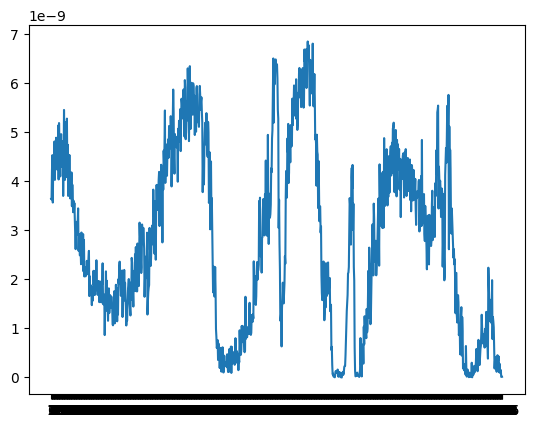

In [26]:
plt.plot(result_container.index.values, np.sqrt(result_container['M2.5_971259_SV'].values**2+result_container['M2.5_971259_SH'].values**2))